In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
import firebase_admin
from firebase_admin import credentials, db
from datetime import datetime  # Untuk konversi timestamp ke human-readable
sns.set_theme(style="whitegrid")
%matplotlib inline 

In [2]:
# Konfigurasi database sumber
source_cred = credentials.Certificate("D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json")
firebase_admin.initialize_app(source_cred, {
    'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
})

In [30]:
station_ids = ['id-03','id-05']
# Input readable date
start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "31-12-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print


1735664400
1798736399


In [39]:
import pandas as pd

# Siapkan dictionary kosong untuk menampung DataFrame yang sudah bersih
all_weather_dataframes = {}

print("Memulai proses pengambilan dan pembersihan data dari Firebase...")
print("="*65)

for station in station_ids:
    try:
        # 1. TARIK DATA DARI FIREBASE
        ref_path = f'/auto_weather_stat/{station}/data'
        ref_data = db.reference(ref_path)
        query_data = ref_data.order_by_key().start_at(str(start_timestamp)).end_at(str(end_timestamp))
        results = query_data.get()
        
        if results:
            # 2. KONVERSI KE DATAFRAME
            df = pd.DataFrame.from_dict(results, orient='index')
            
            # Jika timestamp dari Firebase menjadi Index, turunkan menjadi kolom biasa
            if 'timestamp' not in df.columns:
                df.index.name = 'timestamp'
                df = df.reset_index()
            
            # 3. PENGECEKAN & PENCARIAN LOKASI NULL PADA TIMESTAMP
            null_mask = df['timestamp'].isnull()
            jumlah_null = null_mask.sum()
            
            if jumlah_null > 0:
                # Cari lokasi (nomor baris/index) di mana timestamp bernilai null
                lokasi_null = df[null_mask].index.tolist()
                print(f"   ⚠️ Peringatan: Ditemukan {jumlah_null} data NULL di stasiun {station}.")
                print(f"      -> Baris yang rusak: {lokasi_null}")
                
                # Buang baris yang timestamp-nya null agar tidak membuat error konversi selanjutnya
                df = df.dropna(subset=['timestamp'])
                print("      -> Data NULL telah dihapus.")

            # 4. UBAH TIMESTAMP MENJADI INTEGER
            # Kita ubah ke float dulu untuk jaga-jaga jika Firebase mengirimnya sebagai string '1710000000.0'
            df['timestamp'] = df['timestamp'].astype(float).astype(int)
            
            # 5. UBAH KE DATETIME UTC+7 (ASIA/BANGKOK ATAU ASIA/JAKARTA)
            # Karena timestamp Anda 10 digit, itu artinya formatnya adalah Detik (unit='s')
            df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True)
            
            # Konversi ke waktu lokal WIB (+07:00), lalu buang stempel zonanya agar aman untuk Machine Learning
            df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Bangkok')
            
            # Simpan DataFrame yang sudah sempurna ke dalam dictionary
            all_weather_dataframes[station] = df
            print(f"✅ Berhasil: Stasiun {station} siap! ({len(df)} baris data valid)")
            
        else:
            print(f"⚠️ Kosong: Tidak ada data untuk stasiun {station} pada rentang waktu ini.")
            
    except Exception as e:
        print(f"❌ Error: Gagal memproses data untuk {station}. Detail: {e}")

print("="*65)
print(f"Proses selesai. Data bersih tersedia untuk: {list(all_weather_dataframes.keys())}")

# Untuk melihat hasilnya:
# print(all_weather_dataframes['id-03'].head())
# print(all_weather_dataframes['id-03'].info())

Memulai proses pengambilan dan pembersihan data dari Firebase...
   ⚠️ Peringatan: Ditemukan 2 data NULL di stasiun id-03.
      -> Baris yang rusak: ['1757078040', '1766280720']
      -> Data NULL telah dihapus.
✅ Berhasil: Stasiun id-03 siap! (763472 baris data valid)
✅ Berhasil: Stasiun id-05 siap! (712180 baris data valid)
Proses selesai. Data bersih tersedia untuk: ['id-03', 'id-05']


In [41]:
import os

# 1. Tentukan nama folder target
output_folder = 'raw_data_sensor'

# Buat folder secara otomatis (jika sudah ada, Python tidak akan error berkat exist_ok=True)
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Direktori penyimpanan siap: '{output_folder}/'")
print("="*65)

# 2. Loop melalui dictionary yang berisi DataFrame bersih Anda
for station_id, df in all_weather_dataframes.items():
    try:
        # --- MENAMPILKAN DATA ---
        print(f"\n📊 Menampilkan 3 baris pertama untuk stasiun: {station_id}")
        print(df.head(3)) # Menampilkan sebagian kecil data agar layar tidak penuh
        
        # --- MENYIMPAN DATA KE CSV ---
        # Susun nama file yang rapi
        filename = f"raw_data_{station_id}.csv"
        file_path = os.path.join(output_folder, filename)
        
        # Eksekusi penyimpanan! 
        # Ingat: index=False wajib dipakai agar Pandas tidak membuat kolom angka urut tambahan
        df.to_csv(file_path, index=False)
        
        print(f"💾 Berhasil diekspor: {filename} ({len(df)} baris)")
        
    except Exception as e:
        print(f"❌ Gagal memproses atau menyimpan data untuk {station_id}. Detail: {e}")

print("\n" + "="*65)
print("🎉 SELURUH PROSES SELESAI! Silakan cek folder Anda di sebelah kiri layar.")

📁 Direktori penyimpanan siap: 'raw_data_sensor/'

📊 Menampilkan 3 baris pertama untuk stasiun: id-03
              dew  humidity  pressure  temperature                 timestamp  \
1735664437  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00   
1735664441  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00   
1735664497  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00   

            volt  rainfall  rainrate  
1735664437  4.07       NaN       NaN  
1735664441  4.07       NaN       NaN  
1735664497  4.07       NaN       NaN  
💾 Berhasil diekspor: raw_data_id-03.csv (763472 baris)

📊 Menampilkan 3 baris pertama untuk stasiun: id-05
                 dew  humidity  pressure  rainfall  rainrate  temperature  \
1742366497  27.74858  97.23300  1011.023   11.7348       0.0     28.23109   
1742366512  27.58560  96.49294  1011.033   11.7348       0.0     28.19905   
1742366527  27.56910  96.34035  1011.045   11.7348       0.0     28.20973   

      

In [42]:
# Mengekstrak setiap DataFrame ke variabel terpisah
cuaca3 = all_weather_dataframes.get('id-03')
cuaca4 = all_weather_dataframes.get('id-04')
cuaca5 = all_weather_dataframes.get('id-05')

# Contoh cara mengecek apakah datanya berhasil diekstrak
if cuaca3 is not None:
    print(f"Dimensi data cuaca3: {cuaca3.shape}")
else:
    print("Data cuaca3 kosong/tidak ditemukan.")

Dimensi data cuaca3: (763472, 8)


=== Informasi Missing Values dalam cuaca3 ===

dew                 0
humidity            0
pressure            0
temperature         0
timestamp           0
volt                0
rainfall       732012
rainrate       732012
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
temperature     0.000000
timestamp       0.000000
volt            0.000000
rainfall       95.879351
rainrate       95.879351
dtype: float64


=== Visualisasi Missing Values ===


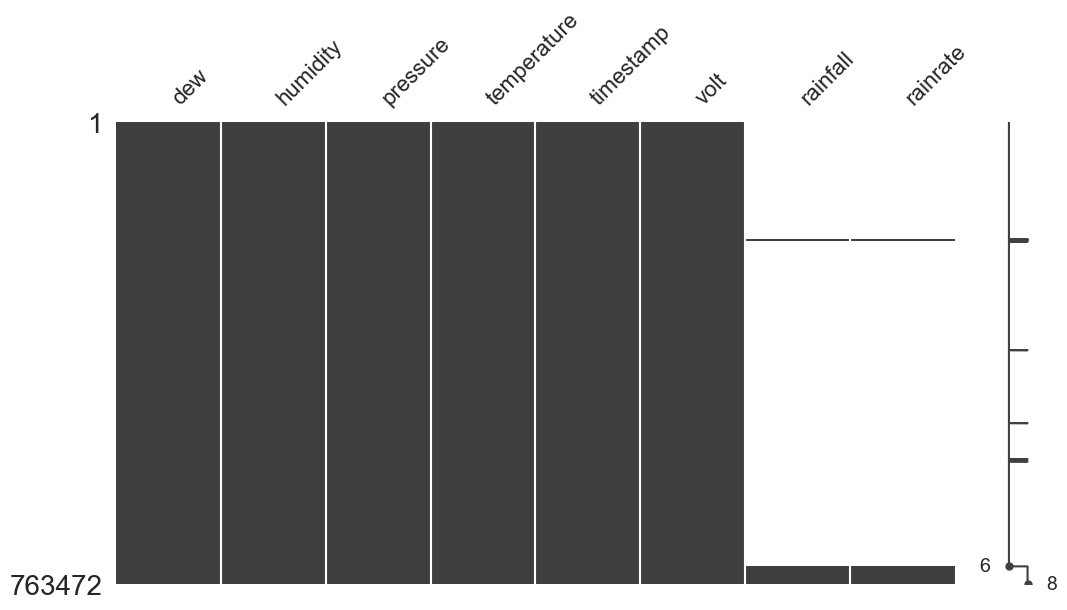


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 732012

Contoh baris dengan null:
              dew  humidity  pressure  temperature                 timestamp  \
1735664437  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00   
1735664441  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00   
1735664497  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00   
1735664501  24.73     100.0   1010.79        24.73 2025-01-01 00:01:41+07:00   
1735664557  24.74     100.0   1010.90        24.74 2025-01-01 00:02:37+07:00   
1735664561  24.74     100.0   1010.90        24.74 2025-01-01 00:02:41+07:00   
1735664617  24.74     100.0   1010.85        24.74 2025-01-01 00:03:37+07:00   
1735664621  24.74     100.0   1010.85        24.74 2025-01-01 00:03:41+07:00   
1735664677  24.73     100.0   1010.86        24.73 2025-01-01 00:04:37+07:00   
1735664681  24.73     100.0   1010.86        24.73 2025-01-01 00:04:41+07:00   

            volt  rainfall

In [43]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca3 ===\n")
print(cuaca3.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca3.isnull().sum() / len(cuaca3)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca3, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca3[cuaca3.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

=== Informasi Missing Values dalam cuaca5 ===

dew                 0
humidity            0
pressure            0
rainfall           71
rainrate           71
temperature         0
timestamp           0
volt              277
tips           595374
rain_rate      710747
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
rainfall        0.009969
rainrate        0.009969
temperature     0.000000
timestamp       0.000000
volt            0.038895
tips           83.598809
rain_rate      99.798787
dtype: float64


=== Visualisasi Missing Values ===


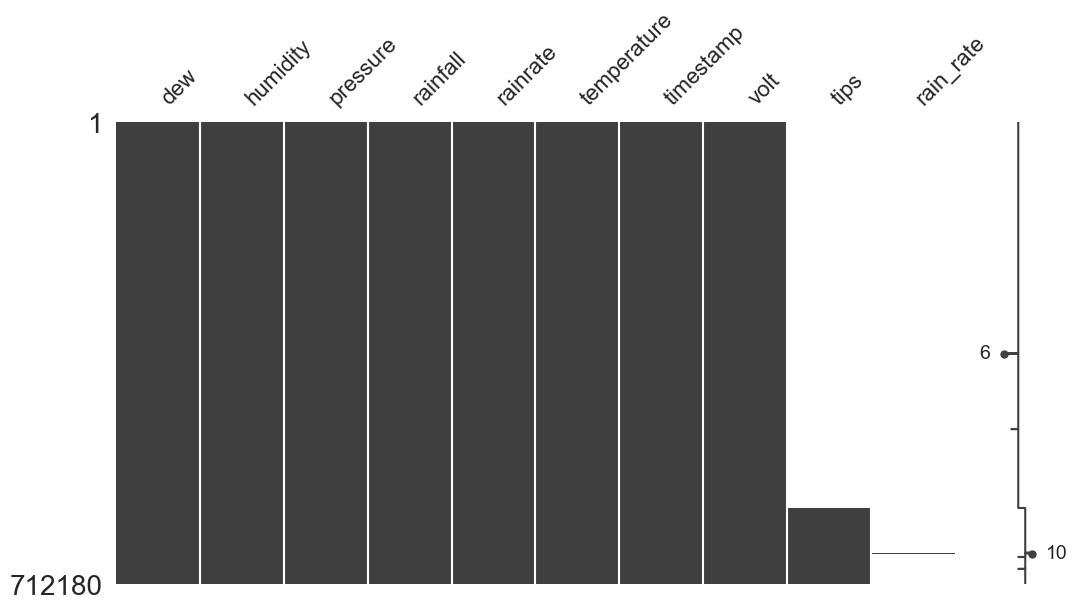


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 710747

Contoh baris dengan null:
                 dew  humidity  pressure  rainfall  rainrate  temperature  \
1742366497  27.74858  97.23300  1011.023   11.7348       0.0     28.23109   
1742366512  27.58560  96.49294  1011.033   11.7348       0.0     28.19905   
1742366527  27.56910  96.34035  1011.045   11.7348       0.0     28.20973   
1742366542  27.68267  96.81529  1011.038   11.7348       0.0     28.23911   
1742366557  27.71058  96.92783  1011.046   11.7348       0.0     28.24712   
1742366572  27.70560  96.80957  1011.059   11.7348       0.0     28.26315   
1742366587  27.63344  96.49294  1011.047   11.7348       0.0     28.24712   
1742366602  27.46198  95.62127  1011.058   11.7348       0.0     28.23109   
1742366617  27.59813  96.20493  1011.048   11.7348       0.0     28.26315   
1742366632  27.58824  96.22400  1011.041   11.7348       0.0     28.24979   

                           timestamp     volt  tips  rain_r

In [44]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca5 ===\n")
print(cuaca5.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca5.isnull().sum() / len(cuaca5)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca5, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca5[cuaca5.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_station_trends(data_dict, column_to_plot, freq='d', agg_method='mean'):
    """
    Membuat plot tren perbandingan dengan metode agregasi dinamis.
    """
    # 1. Konfigurasi Label Frekuensi (KODE DIPERBAIKI KE STANDAR PANDAS BARU)
    freq_config = {
        'd': {'label': 'Harian', 'xlabel': 'Tanggal', 'code': 'D'},   # Gunakan 'D' besar
        'h': {'label': 'Per Jam', 'xlabel': 'Waktu (Jam)', 'code': 'H'}, # Gunakan 'H' besar
        'min': {'label': 'Per Menit', 'xlabel': 'Waktu (Menit)', 'code': 'min'}
    }
    
    selected_freq = freq_config.get(freq, freq_config['d'])
    
    # 2. Konfigurasi Label Agregasi
    agg_labels = {
        'mean': 'Rata-rata',
        'median': 'Median (Nilai Tengah)',
        'max': 'Maksimum (Tertinggi)',
        'min': 'Minimum (Terendah)',
        'sum': 'Total Akumulasi'
    }
    agg_display_name = agg_labels.get(agg_method, agg_method.capitalize())

    # Mulai Plotting
    plt.figure(figsize=(15, 7))
    plot_berhasil = False # Penanda apakah ada yang berhasil di-plot

    # Loop stasiun
    for station_id, df in data_dict.items():
        if column_to_plot not in df.columns:
            print(f"⚠️ Peringatan: Kolom '{column_to_plot}' tidak ada di {station_id}. Skip.")
            continue

        temp_df = df.copy()
        
        # --- PERBAIKAN 1: Pastikan timestamp bisa diakses ---
        if 'timestamp' not in temp_df.columns and temp_df.index.name == 'timestamp':
            temp_df = temp_df.reset_index()

        # Pastikan timestamp adalah datetime
        if not pd.api.types.is_datetime64_any_dtype(temp_df['timestamp']):
             temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

        # --- PERBAIKAN 2: Paksa kolom target menjadi numerik murni ---
        # Jika Firebase mengirim string "28", ini akan memaksanya jadi float 28.0
        temp_df[column_to_plot] = pd.to_numeric(temp_df[column_to_plot], errors='coerce')

        # 3. PROSES GROUPING & AGREGASI DINAMIS
        time_col = f'time_group_{freq}'
        temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
        
        # Lakukan agregasi. Dropna() mencegah eror jika ada data kosong.
        trend_data = temp_df.groupby(time_col)[column_to_plot].agg(agg_method).dropna().reset_index()

        # Jika setelah agregasi datanya kosong, lewati
        if trend_data.empty:
            print(f"⚠️ Peringatan: Data agregasi untuk {station_id} kosong.")
            continue

        # --- PERBAIKAN 3: Tambahkan marker='o' ---
        # Ini memastikan jika datanya hanya 1 titik, titik tersebut akan tetap terlihat!
        plt.plot(
            trend_data[time_col], 
            trend_data[column_to_plot], 
            label=station_id, 
            alpha=0.8, 
            )
        plot_berhasil = True

    # 4. Mempercantik Visualisasi
    plt.xlabel(selected_freq['xlabel'], fontsize=12)
    plt.ylabel(f"{agg_display_name} {column_to_plot.replace('_', ' ').capitalize()}", fontsize=12)
    plt.title(f"Perbandingan {agg_display_name} {column_to_plot} ({selected_freq['label']})", 
              fontsize=14, fontweight='bold')
    
    if plot_berhasil:
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'TIDAK ADA DATA VALID UNTUK DITAMPILKAN', 
                 ha='center', va='center', fontsize=16, color='red', transform=plt.gca().transAxes)
        
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# CARA PEMANGGILAN:
# plot_station_trends(all_weather_dataframes, 'temperature', freq='h', agg_method='max')

Menampilkan plot perbandingan per jam...


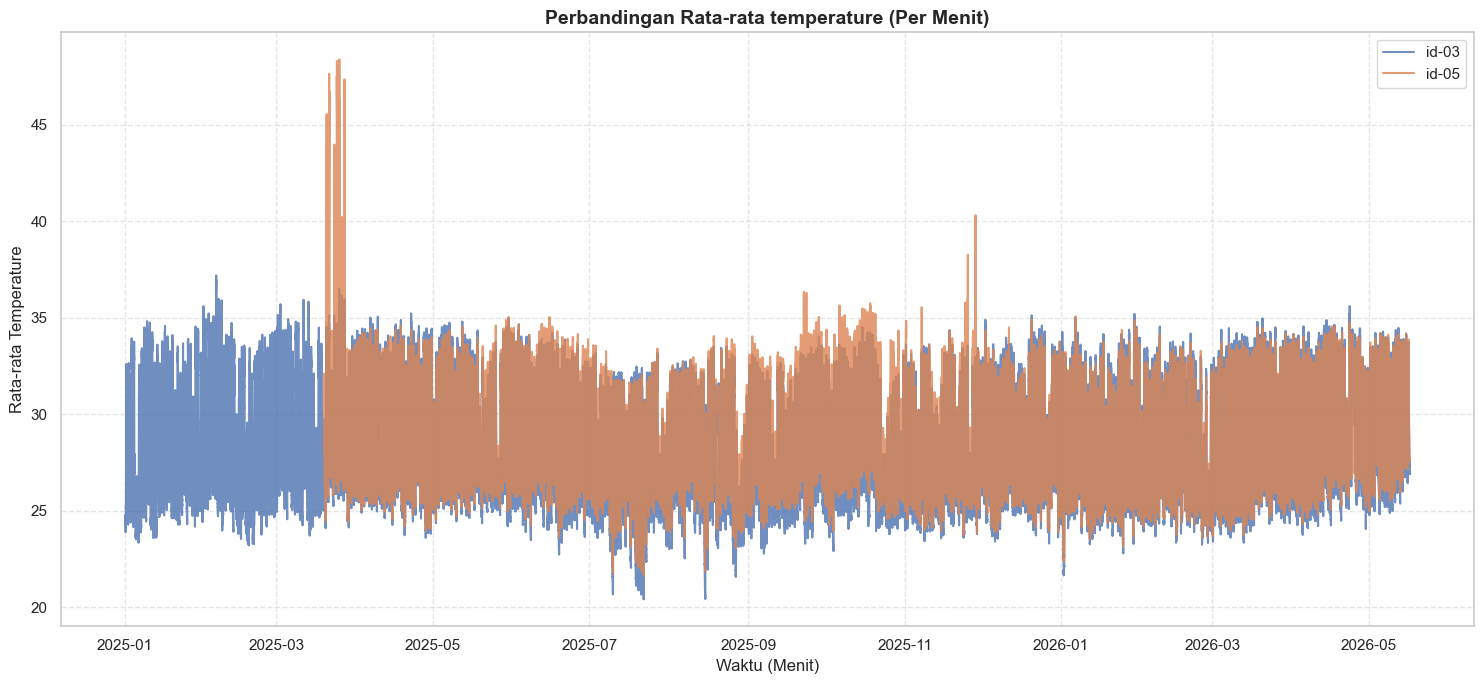

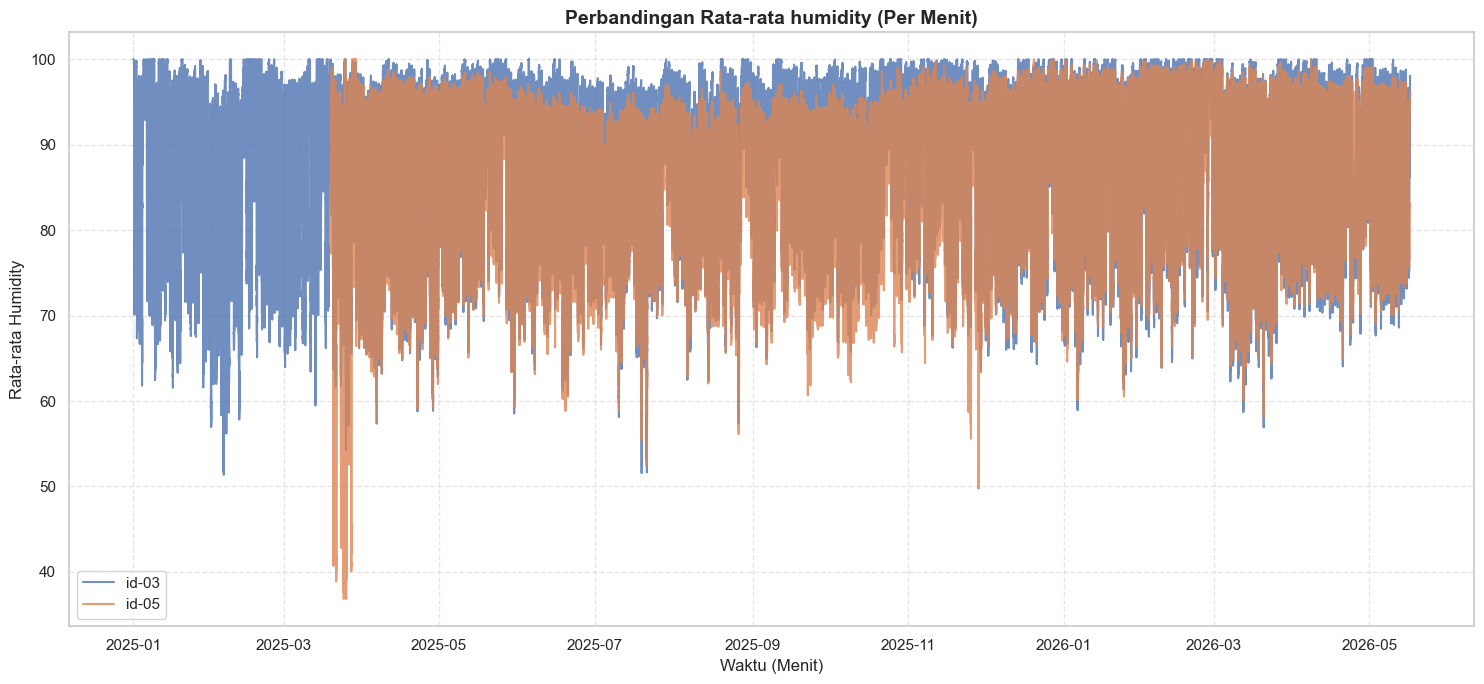

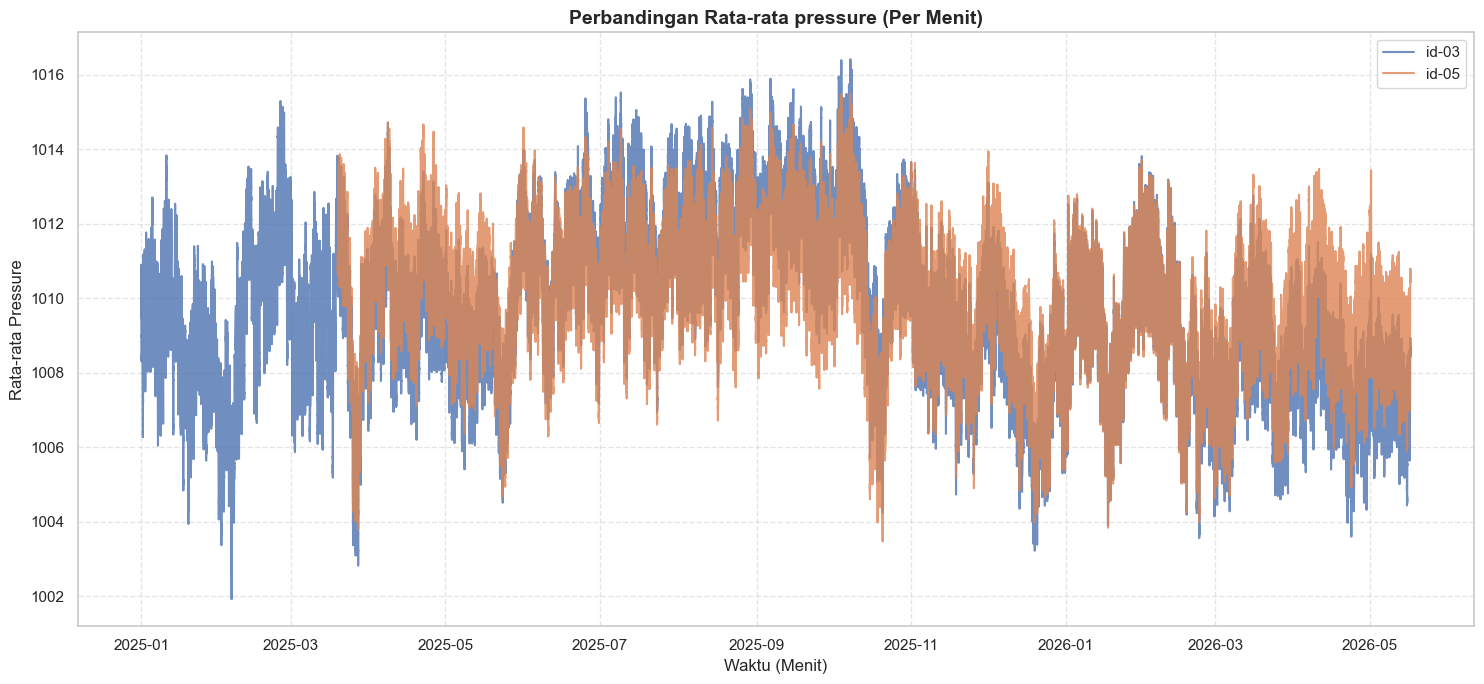

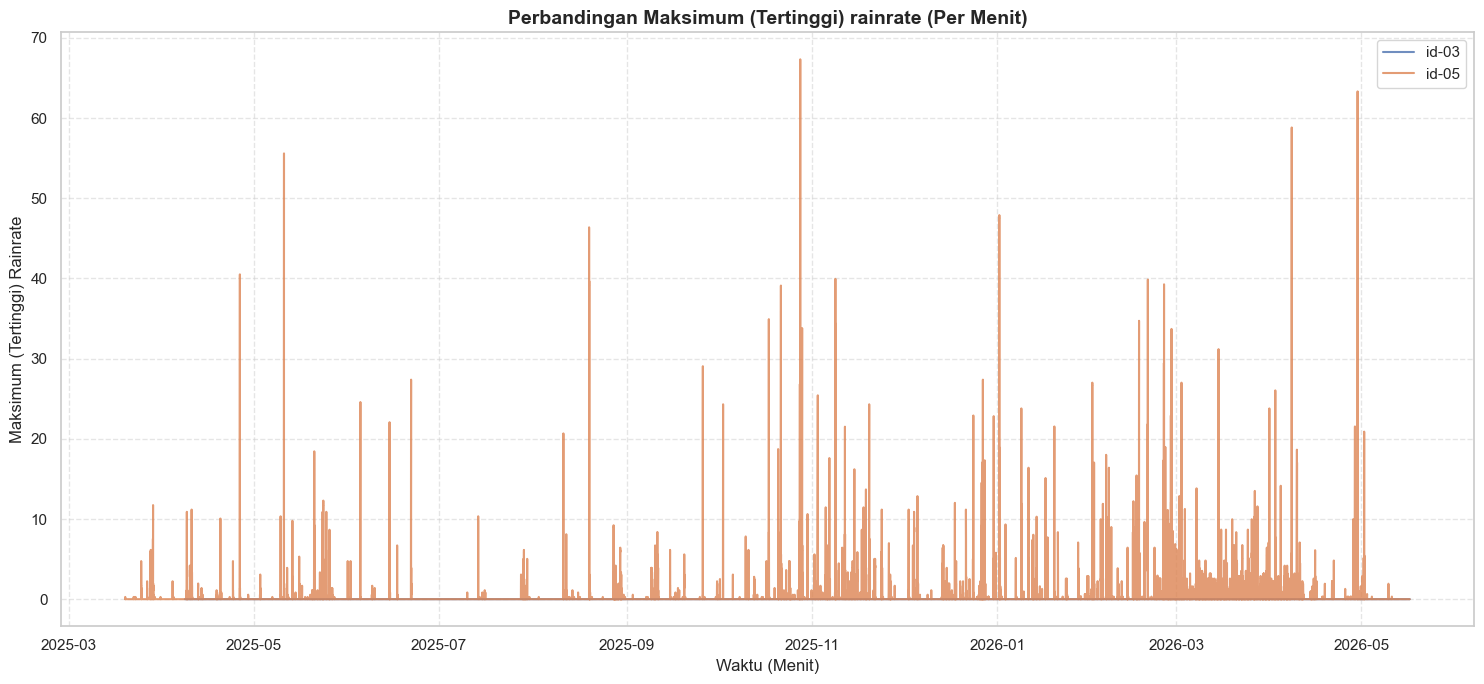

In [46]:
# --- 1. Membuat Plot Rata-rata PER JAM ---
# Cukup atur freq='h'
print("Menampilkan plot perbandingan per jam...")
plot_station_trends(all_weather_dataframes, 'temperature', freq='min', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'humidity', freq='min', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'pressure', freq='min', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'rainrate', freq='min', agg_method='max')


Menampilkan plot perbandingan per hari...


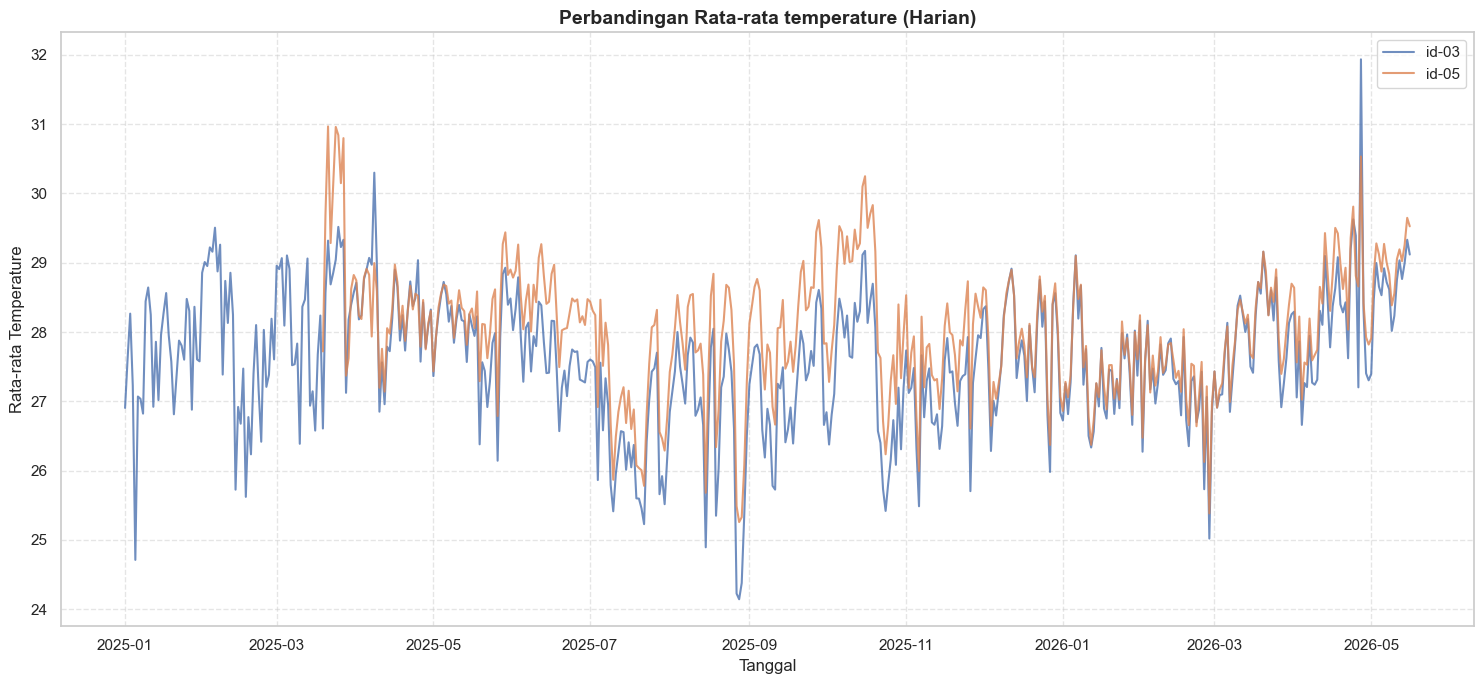

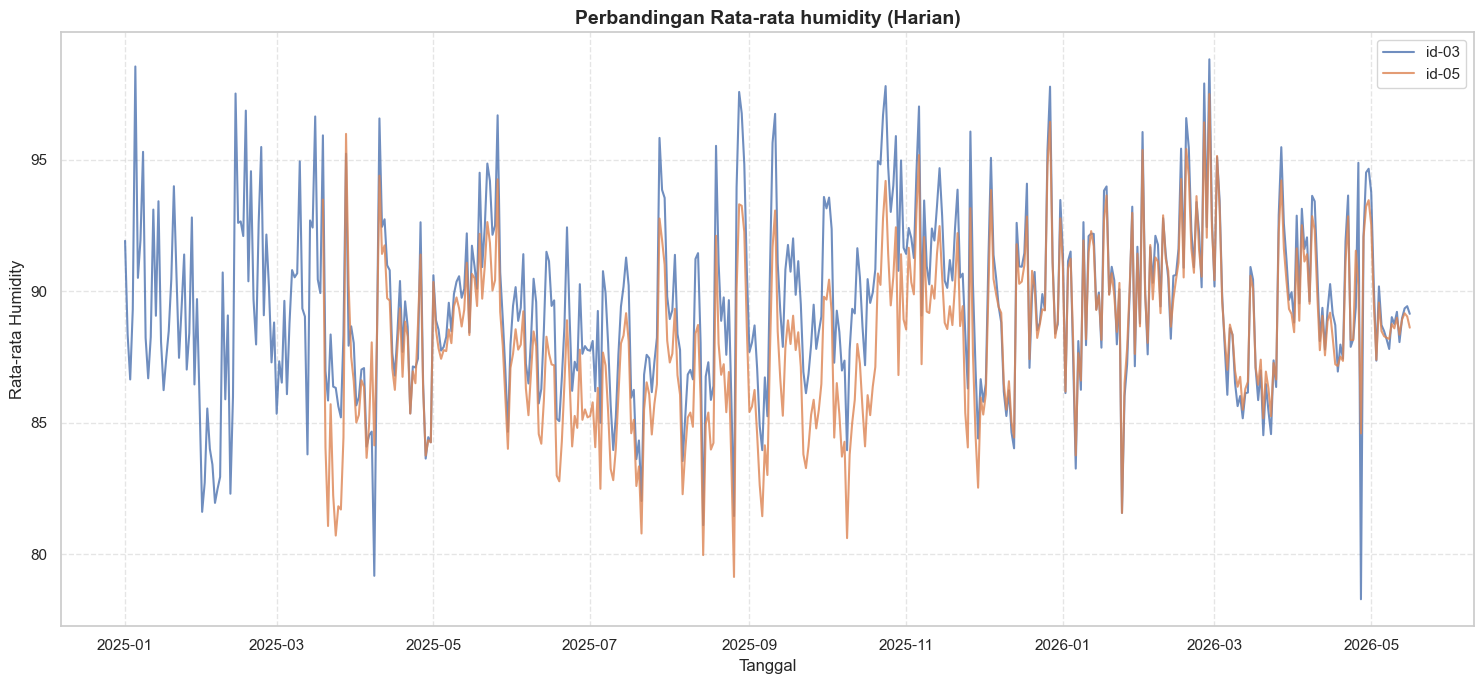

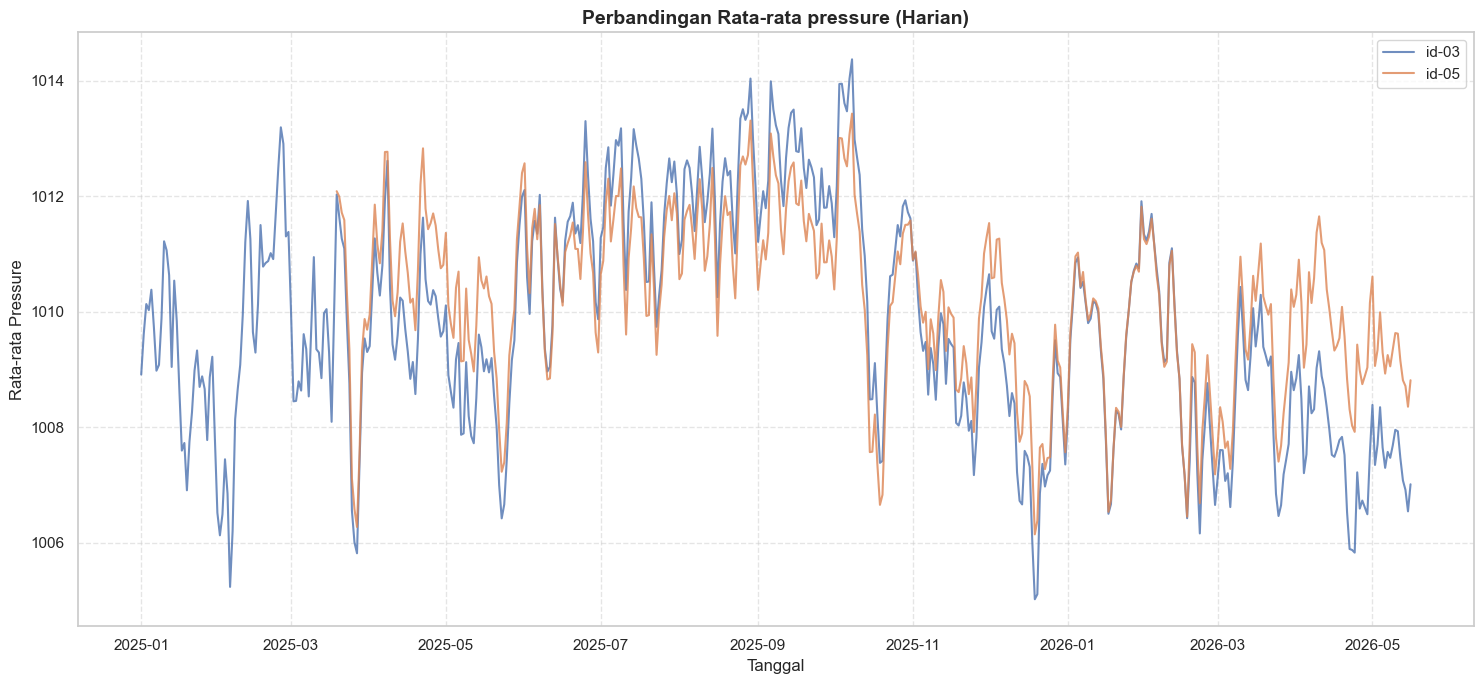

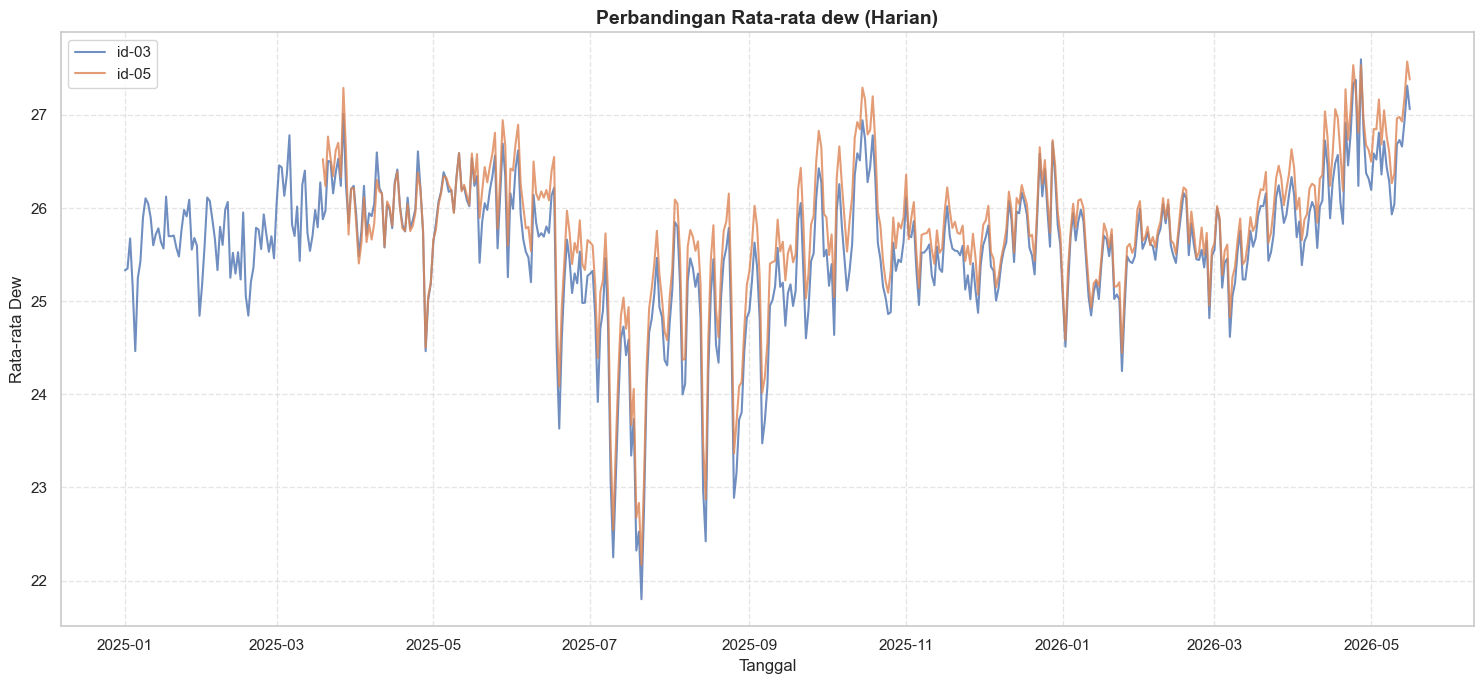

In [13]:
# --- 2. Membuat Plot Rata-rata PER HARI ---
# Gunakan nilai default freq='d' atau tulis secara eksplisit
print("\nMenampilkan plot perbandingan per hari...")
plot_station_trends(all_weather_dataframes, 'temperature', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'humidity', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'pressure', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'dew', freq='d', agg_method='mean')

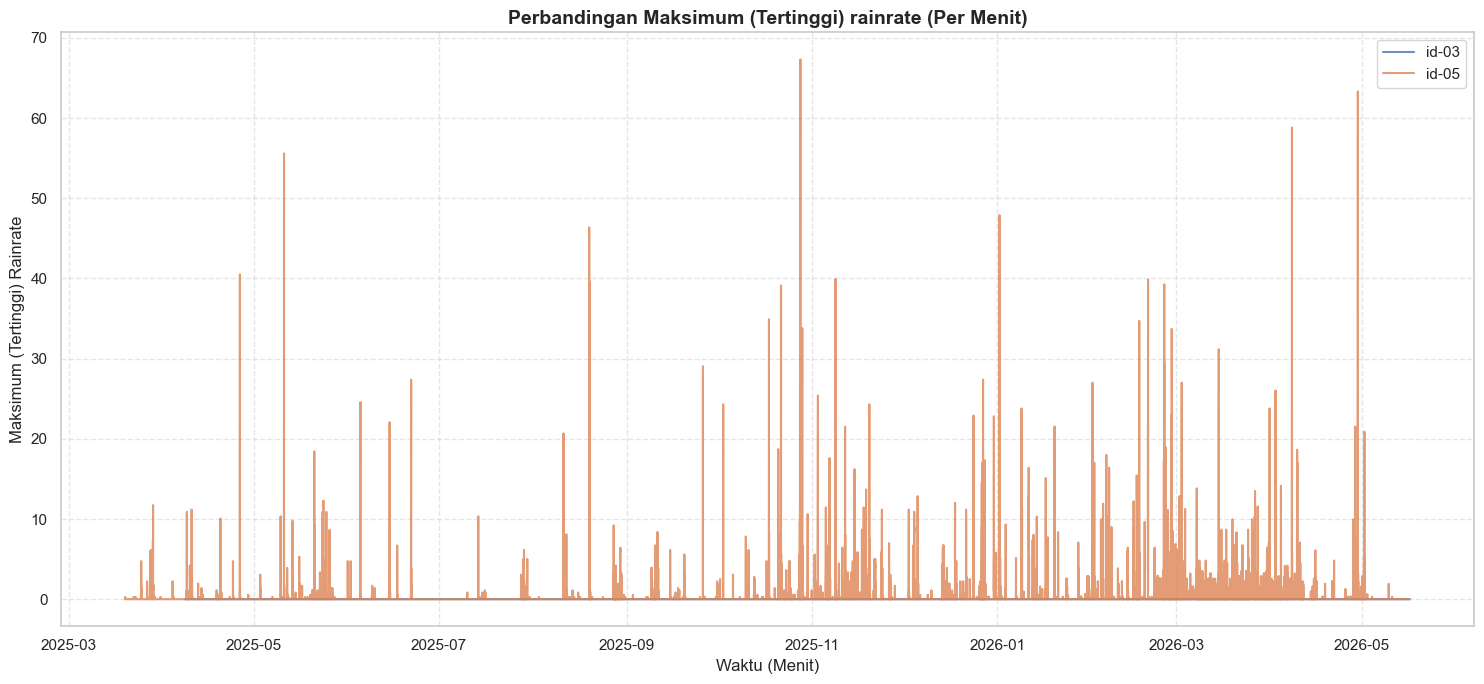

In [14]:
plot_station_trends(all_weather_dataframes, 'rainrate', freq='min', agg_method='max')

In [15]:
cuaca5.describe()

,dew,humidity,pressure,rainfall,rainrate,temperature,volt,tips,rain_rate,hour,minute,day,week,month,year,hour_sin,hour_cos,month_sin,month_cos
count,712057.000000,712057.000000,712057.000000,711986.000000,711986.000000,712057.000000,711780.000000,116683.000000,1433.0,712057.000000,712057.000000,712057.000000,712057.000000,712057.000000,712057.000000,712057.000000,7.120570e+05,712057.000000,7.120570e+05
mean,25.835728,87.925453,1010.201884,7.978803,0.199519,28.171651,4.031120,1.335824,0.0,11.516009,29.509681,15.864956,23.312592,5.774503,2025.269372,-0.001119,2.503378e-03,0.231852,-1.015731e-01
std,1.200958,9.608413,1.929467,15.955019,1.494096,2.911514,0.130965,6.044780,0.0,6.931395,17.319728,8.941877,13.854155,3.205967,0.443634,0.708084,7.061235e-01,0.721604,6.443729e-01
min,20.323490,36.214080,1003.470000,0.000000,0.000000,21.648740,3.292500,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,2025.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000e+00
25%,25.049620,81.272070,1008.930000,0.000000,0.000000,25.972000,3.935000,0.000000,0.0,6.000000,15.000000,8.000000,13.000000,3.000000,2025.000000,-0.707107,-7.071068e-01,-0.500000,-5.000000e-01
50%,25.818550,91.379260,1010.350000,0.643000,0.000000,27.371250,3.948750,0.000000,0.0,12.000000,30.000000,16.000000,19.000000,5.000000,2025.000000,0.000000,6.123234e-17,0.500000,-1.836970e-16
75%,26.606300,95.508740,1011.614000,9.323500,0.000000,30.119020,4.212500,0.000000,0.0,18.000000,45.000000,24.000000,35.000000,8.000000,2026.000000,0.707107,7.071068e-01,0.866025,5.000000e-01
max,31.162000,100.000000,1015.500000,181.330600,67.335400,48.573660,4.250000,197.000000,0.0,23.000000,59.000000,31.000000,52.000000,12.000000,2026.000000,1.000000,1.000000e+00,1.000000,1.000000e+00


In [47]:
import pandas as pd
import numpy as np

# =======================================================
# 1. PERSIAPAN DATA WAKTU (PENTING!)
# =======================================================
# Kita gunakan IF agar aman. Jika kolom 'timestamp' masih ada, 
# kita jadikan dia DatetimeIndex. Jika sudah jadi index, kode ini diabaikan.
if 'timestamp' in cuaca5.columns:
    cuaca5['timestamp'] = pd.to_datetime(cuaca5['timestamp'])
    cuaca5 = cuaca5.sort_values('timestamp').set_index('timestamp')

# =======================================================
# 2. DETEKSI INCREMENT & PENANGANAN RESET ALAT
# =======================================================
# Hitung selisih hujan dari menit ke menit
cuaca5['delta_raw'] = cuaca5['rainrate'].diff()

# Jika negatif (reset), ambil nilai aslinya. Jika positif, ambil selisihnya.
cuaca5['actual_increment'] = np.where(
    cuaca5['delta_raw'] < 0, 
    cuaca5['rainrate'],      
    cuaca5['delta_raw']      
)
cuaca5['actual_increment'] = cuaca5['actual_increment'].fillna(0).clip(lower=0)

# =======================================================
# 3. FILTER OUTLIER (HARD PHYSICAL THRESHOLD)
# =======================================================
BATAS_MAKSIMAL_PER_MENIT = 3.0  # Konservatif untuk menghindari false positive

# Cari indeks mana yang tidak wajar
kondisi_outlier = cuaca5['actual_increment'] > BATAS_MAKSIMAL_PER_MENIT
jumlah_outlier = kondisi_outlier.sum()

print(f"🚨 Terdeteksi {jumlah_outlier} titik outlier (goyangan palsu / lonjakan tak wajar)!")

# HANCURKAN OUTLIER
cuaca5.loc[kondisi_outlier, 'actual_increment'] = 0.0

# =======================================================
# 4. PEMBULATAN TIP (STANDARISASI KE 0.3)
# =======================================================
KONSTANTA_TIP = 0.3
cuaca5['tips_count'] = np.round(cuaca5['actual_increment'] / KONSTANTA_TIP)
cuaca5['increment_fixed'] = cuaca5['tips_count'] * KONSTANTA_TIP

# =======================================================
# 5. REKONSTRUKSI AKUMULASI PER JAM
# =======================================================
# [DIPERBAIKI] Gunakan 'rainrate_fixed' agar data asli 'rainrate' tidak hilang!
# [DIPERBAIKI] Gunakan 'H' besar.
cuaca5['rainrate'] = cuaca5.groupby(cuaca5.index.floor('h'))['increment_fixed'].cumsum()

# =======================================================
# 6. AGREGASI HARIAN / PER JAM
# =======================================================
# [DIPERBAIKI] Resample menggunakan 'H' besar dan ambil kolom 'rainrate'
df_hourly = cuaca5.resample('h').agg({
    'rainrate': 'max',  # Mengambil nilai puncak akumulasi di jam tersebut
    'temperature': 'mean',    
    'humidity': 'mean',       
    'pressure': 'mean',       
    'dew': 'mean'             
})

# Tampilkan hasil
print("✅ Pembersihan dan Agregasi Selesai!")
print(df_hourly.head(10))

🚨 Terdeteksi 128 titik outlier (goyangan palsu / lonjakan tak wajar)!
✅ Pembersihan dan Agregasi Selesai!
                           rainrate  temperature   humidity     pressure  \
timestamp                                                                  
2025-03-19 13:00:00+07:00       0.0    28.163365  94.335827  1011.120959   
2025-03-19 14:00:00+07:00       0.3    29.084335  91.649419  1010.880125   
2025-03-19 15:00:00+07:00       0.0    30.934129  83.867371  1010.835198   
2025-03-19 16:00:00+07:00       0.0    30.897955  83.783592  1010.911521   
2025-03-19 17:00:00+07:00       0.0    28.565734  90.632079  1011.434678   
2025-03-19 18:00:00+07:00       0.0    27.037647  94.918693  1011.847287   
2025-03-19 19:00:00+07:00       0.0    26.603566  96.829447  1012.464685   
2025-03-19 20:00:00+07:00       0.0    26.311772  97.622218  1013.006779   
2025-03-19 21:00:00+07:00       0.0    26.173208  98.185907  1013.179163   
2025-03-19 22:00:00+07:00       0.0    25.865855  98.24067

C:\Users\acer\AppData\Local\Temp\ipykernel_18748\2650539322.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


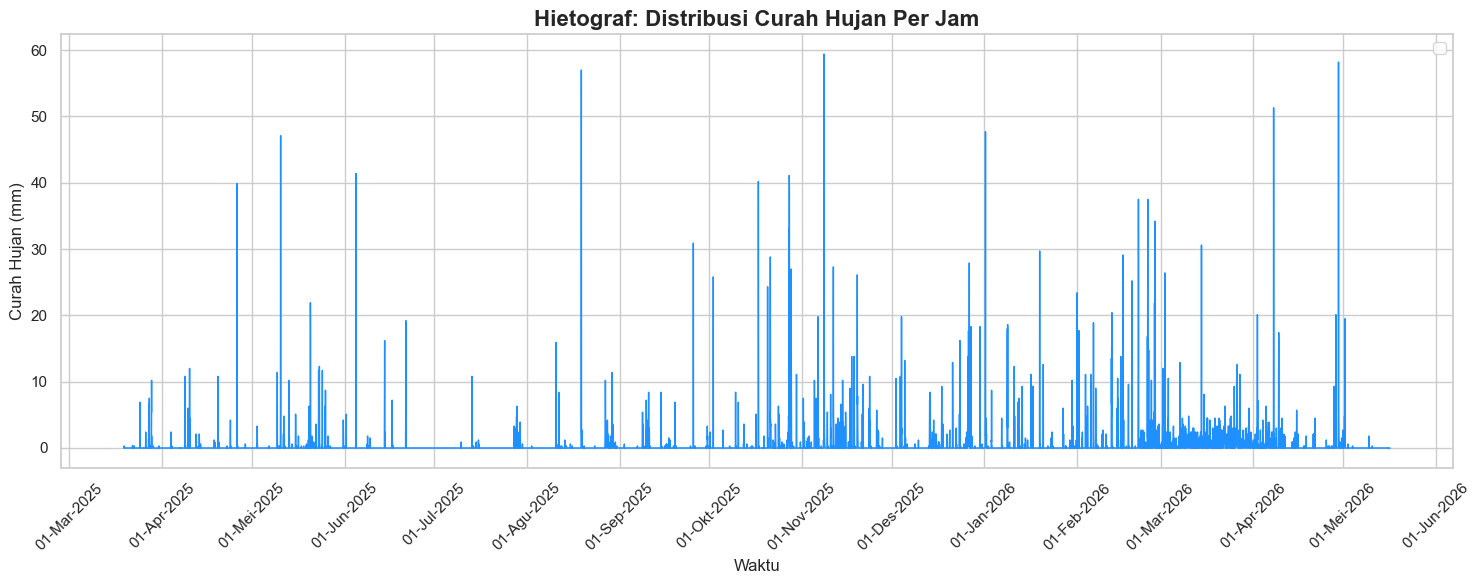

In [48]:
# Set Style biar ganteng
sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# A. PLOT DATA
# Kita pakai bar plot, tapi karena indexnya datetime, kita atur width-nya
# Width 0.03 hari (sekitar 45 menit) biar ada celah dikit antar jam
#plt.bar(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', width=1, label='Curah Hujan (mm/jam)')

# Alternatif kalau data sangat padat (tahunan), pakai ini:
plt.plot(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', lw=1)
plt.fill_between(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', alpha=0.3)

# B. PERCANTIK
plt.title('Hietograf: Distribusi Curah Hujan Per Jam', fontsize=16, fontweight='bold')
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Waktu', fontsize=12)
plt.legend(loc='upper right')

# Format Tanggal di Sumbu X biar rapi
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Label per bulan
plt.xticks(rotation=45)

# Batas Y (opsional, biar kelihatan ruang atasnya)
# plt.ylim(0, df_hourly['rain_mm'].max() * 1.2) 

plt.tight_layout()
plt.show()

In [49]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
PATH_FILE_DESA = 'D:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv'

In [50]:
def load_data(filepath):
    if not os.path.exists(filepath):
        print(f"❌ File tidak ditemukan: {filepath}")
        return None
    try:
        df = pd.read_csv(filepath, index_col='date')
        df.index = pd.to_datetime(df.index, utc=True, errors='coerce')
        df.index = df.index.tz_convert('Asia/Jakarta')
        df.index = df.index.tz_localize(None)
        df = df.sort_index()
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

In [51]:
# 1. Load semua data dulu
df_era5 = load_data(PATH_FILE_DESA)

# ==============================================================================
# 🛠️ TAHAP 1: PERSIAPAN SLICING (Jadikan Naive Sementara)
# ==============================================================================
# Kita ubah dulu ke waktu Jakarta, lalu "copot" labelnya sementara.
# Tujuannya: Agar sintaks slicing .loc['2025'] berjalan mulus tanpa error.

if df_era5.index.tz is not None:
    # 1. Pastikan jamnya sudah digeser ke WIB (+07:00)
    df_era5.index = df_era5.index.tz_convert('Asia/Jakarta')
    
    # 2. HAPUS label zona waktunya sementara
    # Jam 07:00 WIB (+7) akan menjadi jam 07:00 (Polos)
    df_era5.index = df_era5.index.tz_localize(None)

print("Index sementara dikonversi ke Naive (untuk filtering).")

# ==============================================================================
# 🛠️ TAHAP 2: FILTERING & RE-LOCALIZATION (Pasang Lagi Zonanya)
# ==============================================================================

# 1. Ambil data tahun 2025
df_era5 = df_era5.loc['2025':'2026'].copy()

# 2. PASANG KEMBALI ZONA WAKTU ASIA/JAKARTA 
# Karena tadi kita sudah pastikan jamnya benar (langkah Tahap 1.1),
# kita tinggal tempel label 'Asia/Jakarta' lagi.
df_era5.index = df_era5.index.tz_localize('Asia/Jakarta')

print("\n" + "="*40)
print("FILTER BERHASIL & ZONA WAKTU TERPASANG")
print("="*40)
print(f"Zona Waktu: {df_era5.index.tz}") # Harus muncul Asia/Jakarta
print(f"Start     : {df_era5.index.min()}")
print(f"End       : {df_era5.index.max()}")
print(f"Total     : {len(df_era5)} baris")
df_era5.info()

Index sementara dikonversi ke Naive (untuk filtering).

FILTER BERHASIL & ZONA WAKTU TERPASANG
Zona Waktu: Asia/Jakarta
Start     : 2025-01-01 00:00:00+07:00
End       : 2026-05-13 23:00:00+07:00
Total     : 11952 baris
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11952 entries, 2025-01-01 00:00:00+07:00 to 2026-05-13 23:00:00+07:00
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature        11839 non-null  float64
 1   humidity           11839 non-null  float64
 2   dewpoint           11839 non-null  float64
 3   rain_mm            11839 non-null  float64
 4   wind_speed         11839 non-null  float64
 5   wind_gusts         11839 non-null  float64
 6   wind_direction     11839 non-null  float64
 7   pressure           11839 non-null  float64
 8   sealevel_pressure  11839 non-null  float64
 9   sunshine_duration  11839 non-null  float64
 10  direct_radiation   11839 non-null  float64


In [52]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10163 entries, 2025-03-19 13:00:00+07:00 to 2026-05-16 23:00:00+07:00
Freq: h
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rainrate     10124 non-null  float64
 1   temperature  10124 non-null  float64
 2   humidity     10124 non-null  float64
 3   pressure     10124 non-null  float64
 4   dew          10124 non-null  float64
dtypes: float64(5)
memory usage: 476.4 KB


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

def bandingkan_variabel(target_sensor, target_meteo, nama_variabel, satuan, start_time=None, end_time=None):
    """
    Fungsi untuk membandingkan data Sensor vs Open-Meteo/ERA5 dengan filter waktu (opsional)
    Format start_time & end_time: 'YYYY-MM-DD' atau 'YYYY-MM-DD HH:MM:SS'
    """
    print(f"\n" + "="*60)
    print(f"📊 ANALISIS PERBANDINGAN: {nama_variabel.upper()}")
    if start_time or end_time:
        print(f"📅 Periode: {start_time if start_time else 'Awal'} s.d {end_time if end_time else 'Akhir'}")
    print("="*60)

    # 1. SIAPKAN DATA & PENGECEKAN KOLOM
    if target_sensor not in df_hourly.columns:
        print(f"❌ Error: Kolom sensor '{target_sensor}' tidak ditemukan di df_hourly.")
        return
    if target_meteo not in df_era5.columns:
        print(f"❌ Error: Kolom model '{target_meteo}' tidak ditemukan di df_era5.")
        return

    # --- TRIK ROBUST: Ganti nama kolom sebelum digabung ---
    s_sensor = df_hourly[target_sensor].rename('Nilai_Sensor')
    s_meteo = df_era5[target_meteo].rename('Nilai_Satelit')

    # Gabungkan berdasarkan index waktu yang sama
    df_compare = pd.concat([s_sensor, s_meteo], axis=1)
    
    # --- FILTER WAKTU ---
    if start_time and end_time:
        df_compare = df_compare.loc[start_time:end_time]
    elif start_time:
        df_compare = df_compare.loc[start_time:]
    elif end_time:
        df_compare = df_compare.loc[:end_time]
    
    # Cek apakah data kosong setelah difilter
    if df_compare.empty:
        print("⚠️ Peringatan: Data kosong pada rentang waktu tersebut!")
        return

    # Hapus NaN (hanya pertahankan waktu di mana kedua alat menyala/ada datanya)
    df_compare = df_compare.dropna()
    
    # Ambil Series untuk perhitungan statistik
    x = df_compare['Nilai_Sensor']
    y = df_compare['Nilai_Satelit']

    # 2. HITUNG STATISTIK ERROR
    mae = mean_absolute_error(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    bias_max = (y - x).max()
    bias_min = (y - x).min()
    bias = (y - x).mean()    
    
    # Korelasi
    corr_p = x.corr(y, method='pearson')
    corr_s, _ = spearmanr(x, y)

    print(f"1. Statistik Error:")
    print(f"   - MAE  : {mae:.2f} {satuan}")
    print(f"   - RMSE : {rmse:.2f} {satuan}")
    print(f"   - Bias Max (Model - Sensor): {bias_max:.2f} {satuan}")
    print(f"   - Bias Min (Model - Sensor): {bias_min:.2f} {satuan}")
    print(f"   - Bias (Rata-rata Selisih): {bias:.2f} {satuan}")

    print(f"\n2. Statistik Hubungan:")
    print(f"   - Pearson (Linear)    : {corr_p:.4f}")
    print(f"   - Spearman (Ranking)  : {corr_s:.4f}")

    # 3. VISUALISASI
    plt.figure(figsize=(14, 10))

    # --- PLOT A: TIME SERIES (Grafik Garis) ---
    plt.subplot(2, 1, 1)
    
    plt.plot(df_compare.index, df_compare['Nilai_Sensor'], 
             label=f'Sensor IoT ({target_sensor})', 
             color='blue', alpha=0.8)
    
    plt.plot(df_compare.index, df_compare['Nilai_Satelit'], 
             label=f'ERA5 ({target_meteo})', 
             color='red', alpha=0.6)
    
    plt.title(f'Time Series: {nama_variabel} (Sensor vs ERA5)', fontsize=14, fontweight='bold')
    plt.ylabel(f'{nama_variabel} ({satuan})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- PLOT B: SCATTER PLOT (Validasi Linearitas) ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=x, y=y, alpha=0.3, color='purple', edgecolor=None)

    # Garis Identitas 1:1
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Garis Sempurna (1:1)')

    # Garis Regresi (Trend Asli)
    sns.regplot(x=x, y=y, scatter=False, color='red', label='Trendline', line_kws={'linestyle':':'})

    plt.xlabel(f'Sensor IoT ({satuan})')
    plt.ylabel(f'ERA5 ({satuan})')
    plt.title(f'Scatter Plot: Korelasi {nama_variabel} (r={corr_p:.2f})', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


📊 ANALISIS PERBANDINGAN: SUHU UDARA
📅 Periode: 2025-03-01 00:00:00 s.d 2025-04-30 23:59:59
1. Statistik Error:
   - MAE  : 1.44 °C
   - RMSE : 2.26 °C
   - Bias Max (Model - Sensor): 3.11 °C
   - Bias Min (Model - Sensor): -14.50 °C
   - Bias (Rata-rata Selisih): -1.06 °C

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8631
   - Spearman (Ranking)  : 0.8823


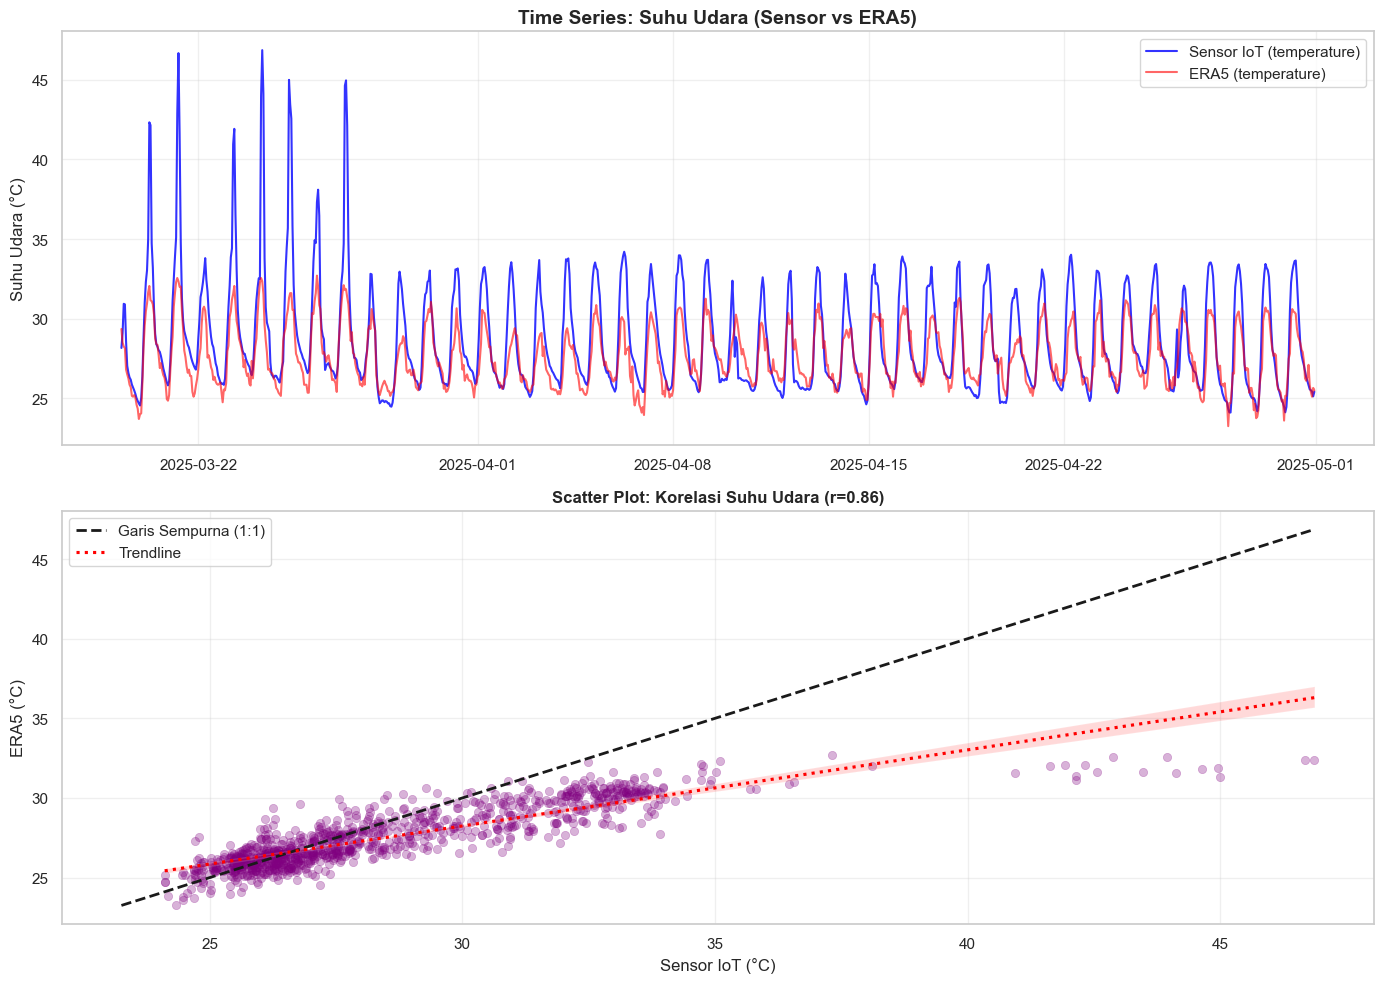


📊 ANALISIS PERBANDINGAN: KELEMBAPAN
📅 Periode: 2025-03-01 00:00:00 s.d 2025-04-30 23:59:59
1. Statistik Error:
   - MAE  : 5.38 %
   - RMSE : 6.63 %
   - Bias Max (Model - Sensor): 24.90 %
   - Bias Min (Model - Sensor): -20.84 %
   - Bias (Rata-rata Selisih): -3.14 %

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8688
   - Spearman (Ranking)  : 0.8590


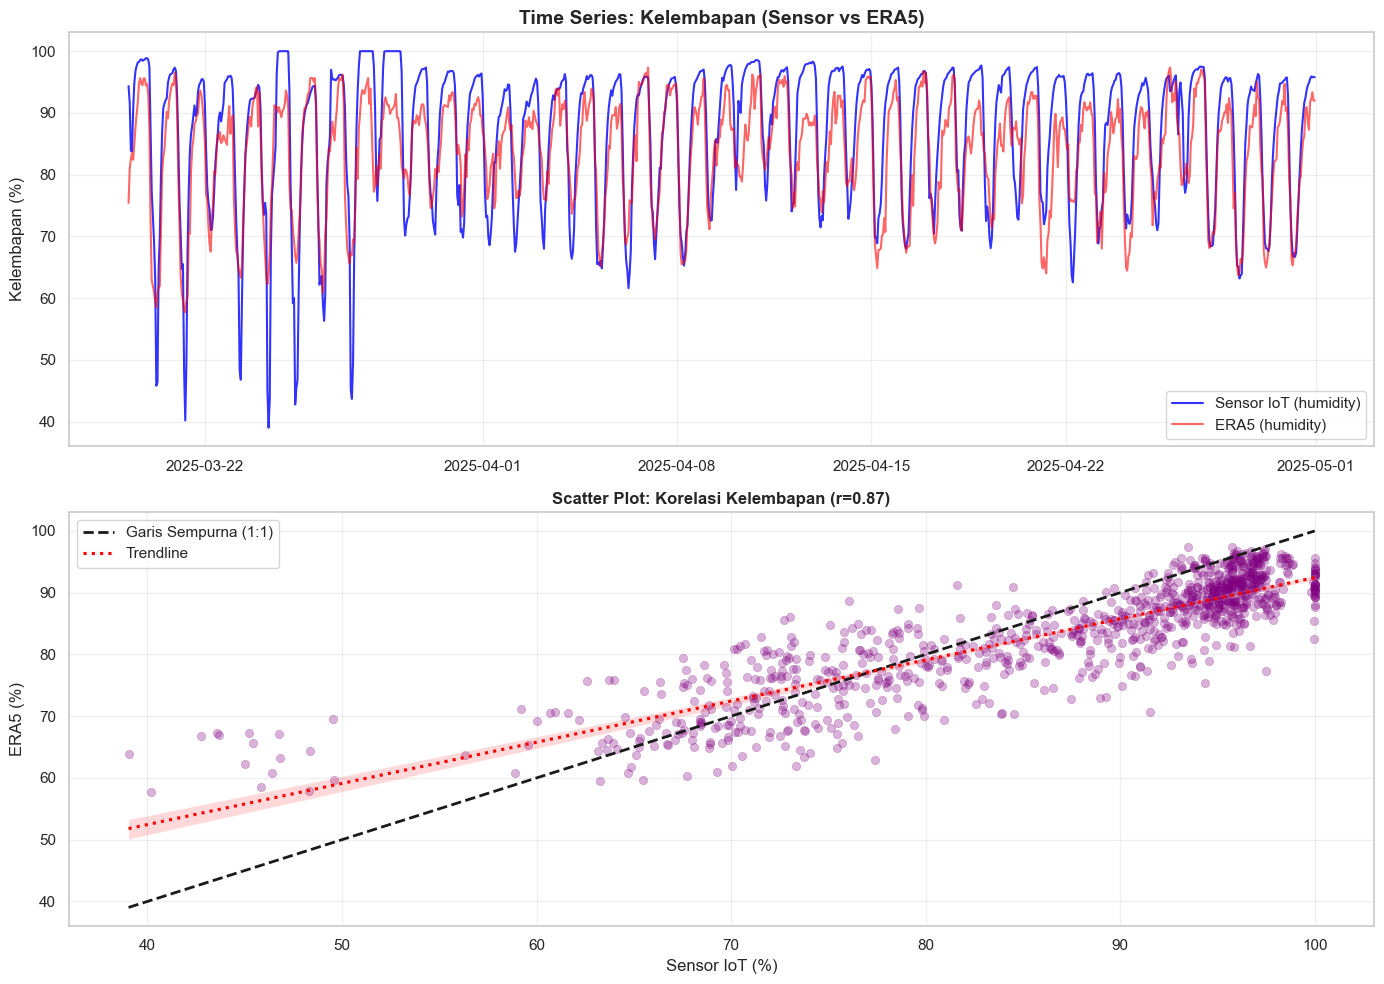


📊 ANALISIS PERBANDINGAN: TEKANAN UDARA
📅 Periode: 2025-03-01 00:00:00 s.d 2025-04-30 23:59:59
1. Statistik Error:
   - MAE  : 0.80 hPa
   - RMSE : 0.92 hPa
   - Bias Max (Model - Sensor): 0.78 hPa
   - Bias Min (Model - Sensor): -2.37 hPa
   - Bias (Rata-rata Selisih): -0.77 hPa

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.9655
   - Spearman (Ranking)  : 0.9532


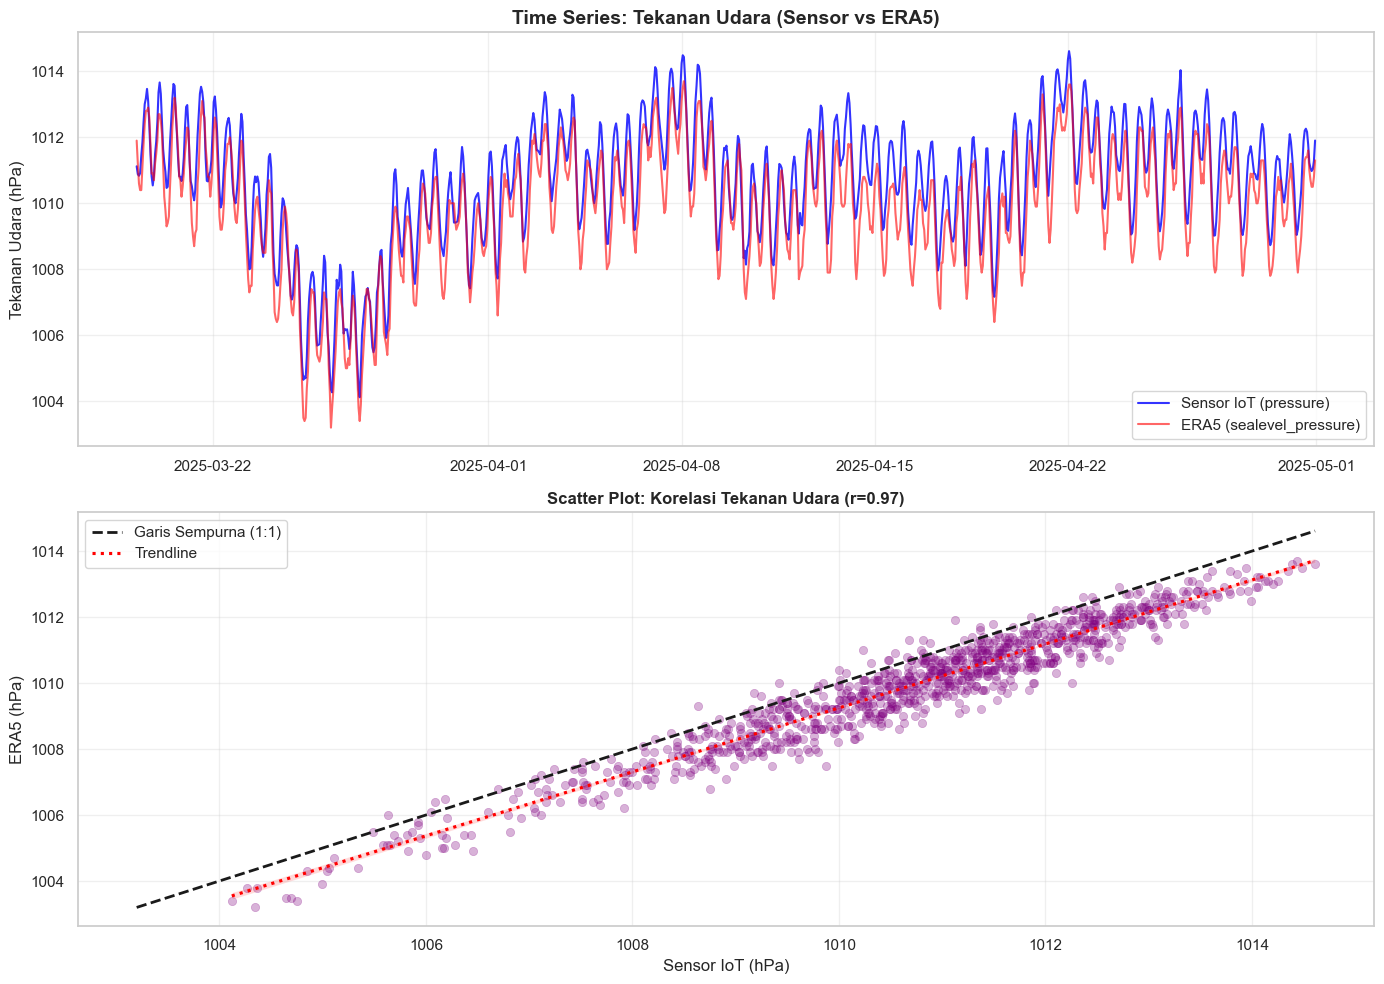


📊 ANALISIS PERBANDINGAN: CURAH HUJAN
📅 Periode: 2025-03-01 00:00:00 s.d 2025-04-30 23:59:59
1. Statistik Error:
   - MAE  : 0.35 mm/jam
   - RMSE : 1.63 mm/jam
   - Bias Max (Model - Sensor): 7.90 mm/jam
   - Bias Min (Model - Sensor): -39.90 mm/jam
   - Bias (Rata-rata Selisih): 0.04 mm/jam

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.0313
   - Spearman (Ranking)  : 0.1039


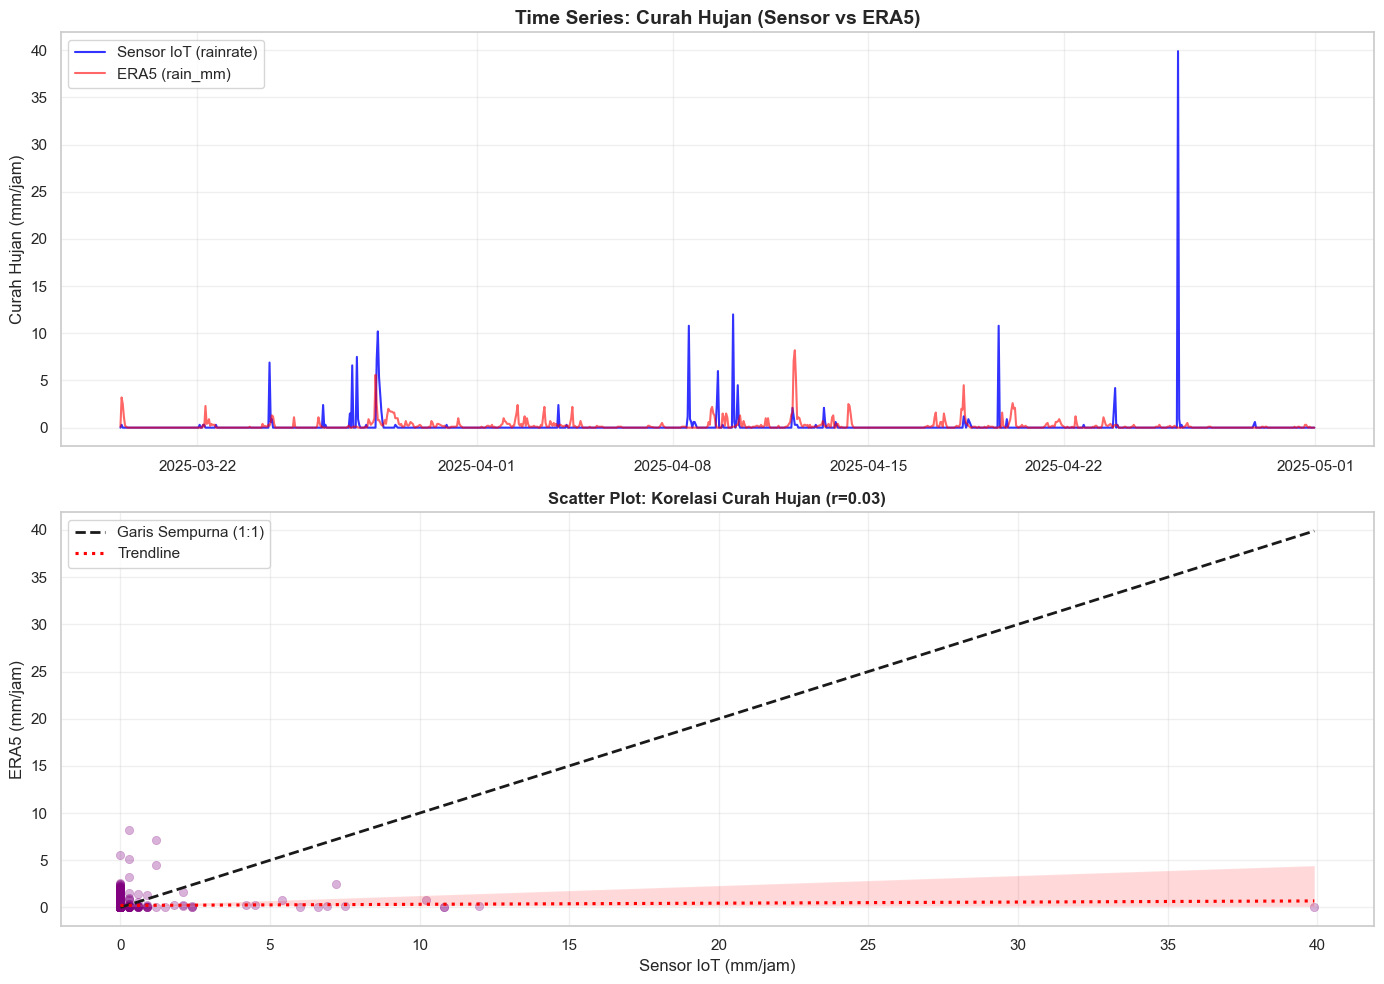

In [67]:
start_time = '2025-03-01 00:00:00'
end_time = '2025-04-30 23:59:59'
# 1. Tanpa filter waktu (menampilkan semua data seperti sebelumnya)
bandingkan_variabel('temperature', 'temperature', 'Suhu Udara', '°C', start_time=start_time, end_time=end_time)

# 2. Menggunakan start_time (Contoh: Membuang outlier di bulan Maret, mulai analisis dari April 2025)
bandingkan_variabel('humidity', 'humidity', 'Kelembapan', '%', start_time=start_time, end_time=end_time)

# 3. Menggunakan start_time dan end_time (Contoh: Analisis spesifik 1 bulan saja)
bandingkan_variabel('pressure', 'sealevel_pressure', 'Tekanan Udara', 'hPa', start_time=start_time, end_time=end_time)

# 4. Filter spesifik dengan jam (Contoh: Badai ekstrem dalam 2 hari)
bandingkan_variabel('rainrate', 'rain_mm', 'Curah Hujan', 'mm/jam', start_time=start_time, end_time=end_time)

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. FUNGSI PIPELINE: REINDEXING + HAMPEL FILTER + IMPUTASI
# ==============================================================================
def bersihkan_data_hourly(df_hourly):
    """
    Melakukan Reindexing, Hampel Filter (untuk suhu, kelembapan, tekanan),
    dan Penambalan (Imputasi) secara otomatis.
    """
    print("⚙️ Memulai Pipeline Pembersihan Data Per Jam...")
    
    # --- TAHAP 1: REINDEXING ---
    waktu_mulai = df_hourly.index.min()
    waktu_akhir = df_hourly.index.max()
    master_index = pd.date_range(start=waktu_mulai, end=waktu_akhir, freq='h')
    
    df_reindexed = df_hourly.reindex(master_index)
    df_reindexed.index.name = 'timestamp'
    
    # Simpan versi mentah (setelah direindex tapi sebelum difilter) untuk perbandingan plot
    df_raw = df_reindexed.copy()
    
    # --- TAHAP 2: HAMPEL FILTER & IMPUTASI (Khusus Parameter Melengkung) ---
    kolom_sensor = ['temperature', 'humidity', 'pressure', 'dew', 'volt']
    window = 24
    n_sigmas = 3
    
    for col in kolom_sensor:
        if col in df_reindexed.columns:
            # 1. Deteksi Outlier dengan Hampel Filter
            rolling_median = df_reindexed[col].rolling(window=window, center=True).median()
            deviasi = np.abs(df_reindexed[col] - rolling_median)
            mad = deviasi.rolling(window=window, center=True).median()
            threshold = n_sigmas * 1.4826 * mad
            outlier_idx = deviasi > threshold
            
            # Hancurkan outlier (jadikan NaN)
            df_reindexed.loc[outlier_idx, col] = np.nan
            
            # 2. Imputasi Spline (Menambal NaN dengan lekukan alami)
            # Digunakan 'pchip' atau 'polynomial' agar lekukannya mulus
            df_reindexed[col] = df_reindexed[col].interpolate(method='polynomial', order=3, limit_direction='both')
            
            # Tambalan darurat jika ada NaN di ujung awal/akhir data
            df_reindexed[col] = df_reindexed[col].bfill().ffill()

    # --- TAHAP 3: PENANGANAN KHUSUS HUJAN (STOKASTIK) ---
    kolom_hujan = ['rain_mm', 'rainfall', 'rainrate']
    for col in kolom_hujan:
        if col in df_reindexed.columns:
            # Hujan bolong JANGAN di-interpolasi. Isi dengan 0.
            df_reindexed[col] = df_reindexed[col].fillna(0.0)

    print("✅ Pipeline Selesai! Data sudah Reindexed, Bebas Outlier, dan Tertambal.")
    return df_raw, df_reindexed

# ==============================================================================
# 2. FUNGSI VISUALISASI SEBELUM VS SESUDAH
# ==============================================================================
def plot_sebelum_sesudah(df_raw, df_clean, nama_kolom, satuan, start_time=None, end_time=None):
    """
    Menampilkan grafik perbandingan data mentah (ada outlier/bolong) 
    vs data bersih (mulus/tertambal) dengan filter rentang waktu.
    """
    # Potong data berdasarkan filter waktu jika diberikan
    if start_time and end_time:
        df_raw_plot = df_raw.loc[start_time:end_time]
        df_clean_plot = df_clean.loc[start_time:end_time]
        judul_waktu = f"({start_time} s.d {end_time})"
    else:
        df_raw_plot = df_raw
        df_clean_plot = df_clean
        judul_waktu = "(Semua Data)"

    plt.figure(figsize=(15, 6))
    
    # Plot Data Mentah (Diberi warna merah pudar, titik besar agar terlihat jika outlier)
    plt.plot(df_raw_plot.index, df_raw_plot[nama_kolom], 
             color='red', alpha=0.4, label='Sebelum (Kotor/Outlier/Bolong)', 
             marker='x', markersize=4, linestyle='--')
    
    # Plot Data Bersih (Diberi warna biru tebal)
    plt.plot(df_clean_plot.index, df_clean_plot[nama_kolom], 
             color='blue', linewidth=2, label='Sesudah (Filter Hampel & Imputasi)')
    
    # Mempercantik plot
    plt.title(f'Efek Pembersihan & Imputasi: {nama_kolom.capitalize()} {judul_waktu}', fontsize=14, fontweight='bold')
    plt.ylabel(f'{nama_kolom.capitalize()} ({satuan})', fontsize=12)
    plt.xlabel('Waktu', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 🚀 CARA PENGGUNAAN (EKSEKUSI)
# ==============================================================================

# Asumsi df_hourly adalah data stasiun Anda (misal id-03) yang sudah diagregasi per jam
# df_raw_03, df_clean_03 = bersihkan_data_hourly(df_hourly)

# Set waktu sesuai contoh Anda
# start_time = '2025-03-01 00:00:00'
# end_time = '2025-04-30 23:59:59'

# Tampilkan grafiknya!
# plot_sebelum_sesudah(df_raw_03, df_clean_03, 'temperature', '°C', start_time, end_time)

In [74]:
# 1. Terapkan filter pada kolom temperature
df_raw_05, df_clean_05 = bersihkan_data_hourly(df_hourly)

⚙️ Memulai Pipeline Pembersihan Data Per Jam...
✅ Pipeline Selesai! Data sudah Reindexed, Bebas Outlier, dan Tertambal.


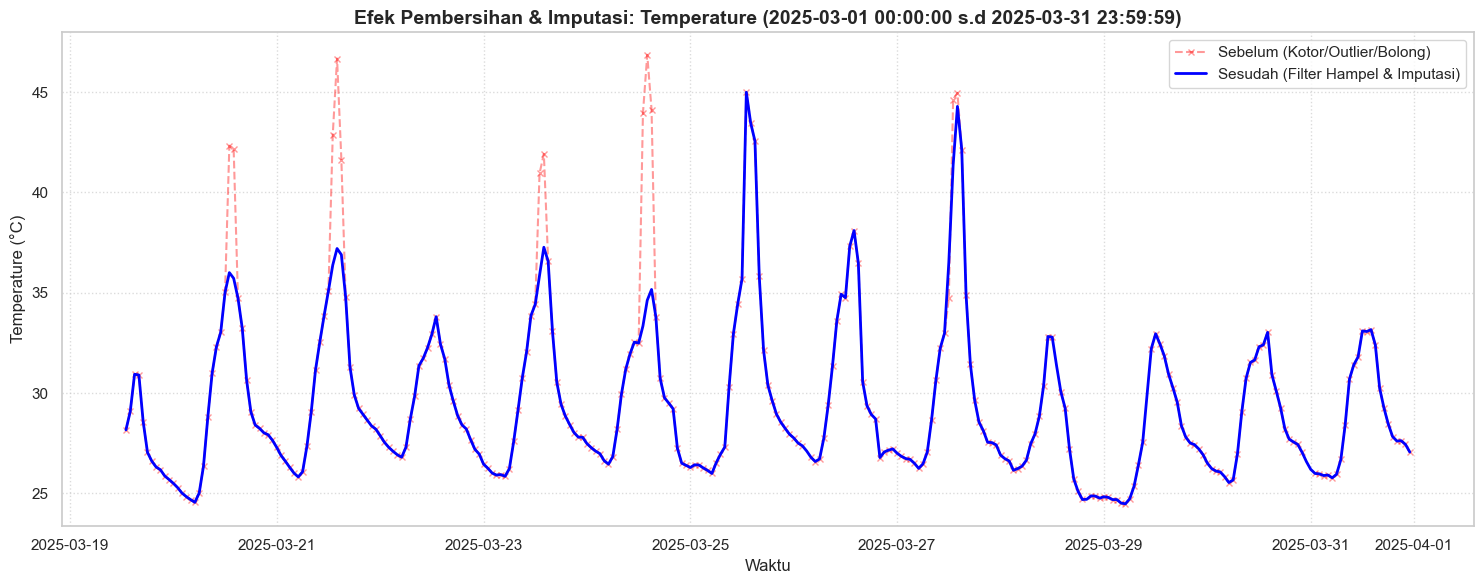

In [75]:
# 2. Plot hasilnya sesuai rentang waktu Anda
start_time = '2025-03-01 00:00:00'
end_time = '2025-03-31 23:59:59'

plot_sebelum_sesudah(df_raw_05, df_clean_05, 'temperature', '°C', start_time, end_time)